In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
from fipcore import mms_name_make

In [2]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

In [5]:
bin_width_frac = 0.25
species = 'e'
project_root = os.path.dirname(os.getcwd())
data_dir = os.path.join(project_root, "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, mms_name_make(hfile_pref, trange[0], trange[1]))
with h5py.File(hfile, "r") as f:
    bvdf_vol = f["fac"]["bvdf_vol"][...]

In [6]:
bvdf_vol.shape

(28, 28, 28, 133)

In [7]:
fx = np.nansum(bvdf_vol, axis=(1,2))
fy = np.nansum(bvdf_vol, axis=(0,2))
fz = np.nansum(bvdf_vol, axis=(0,1))

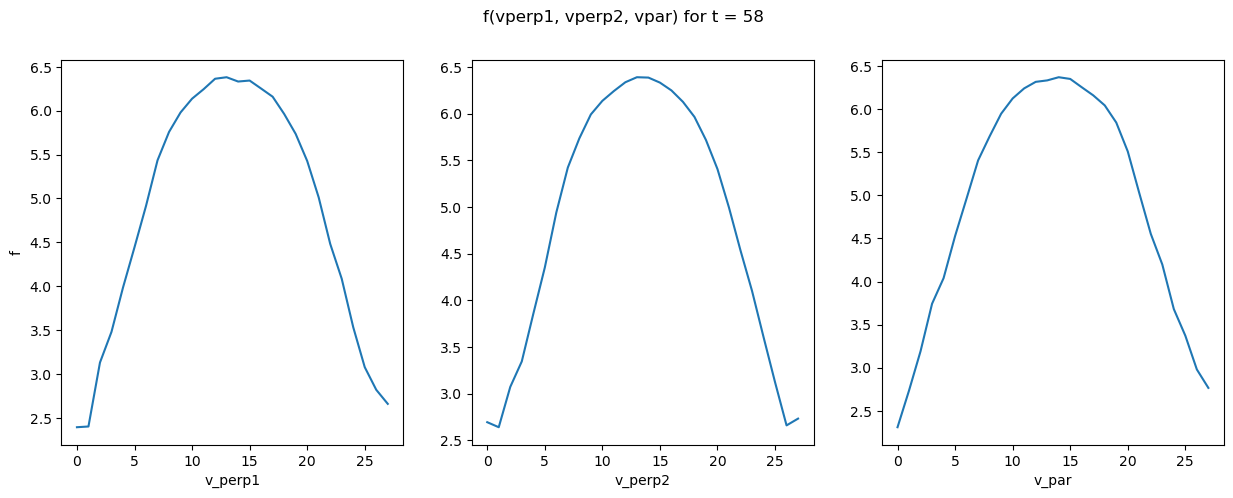

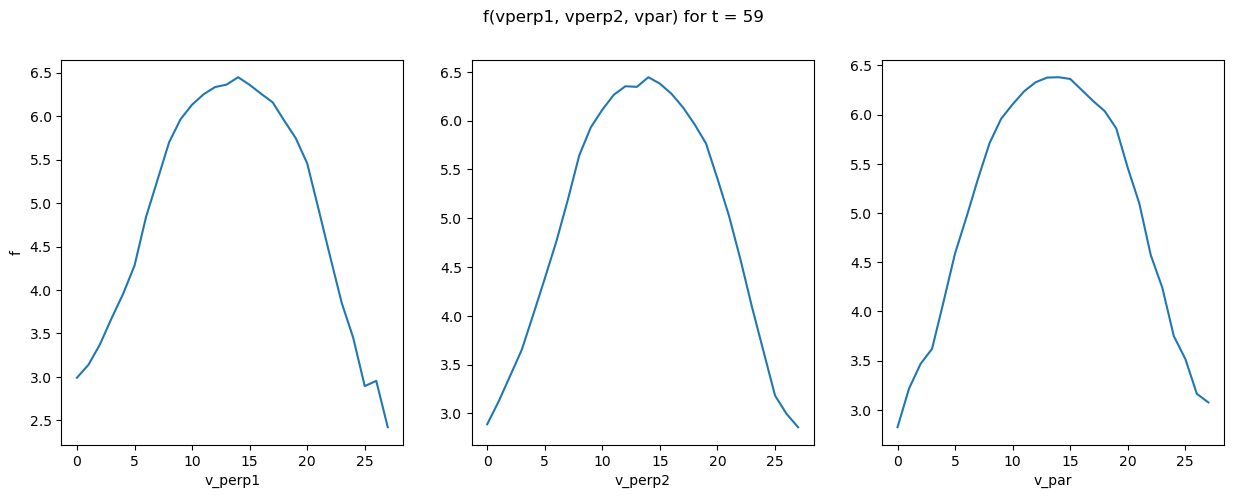

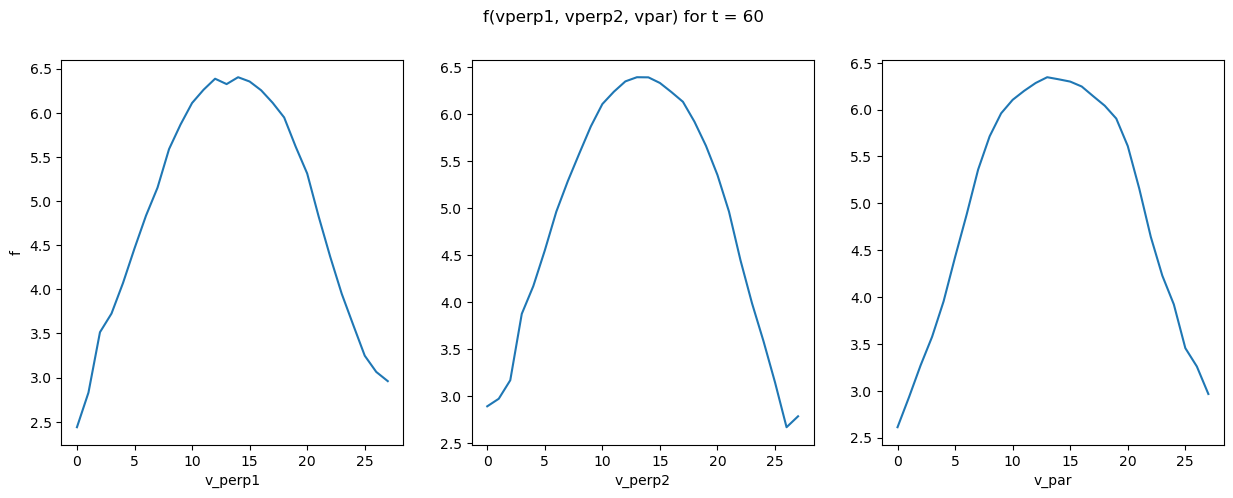

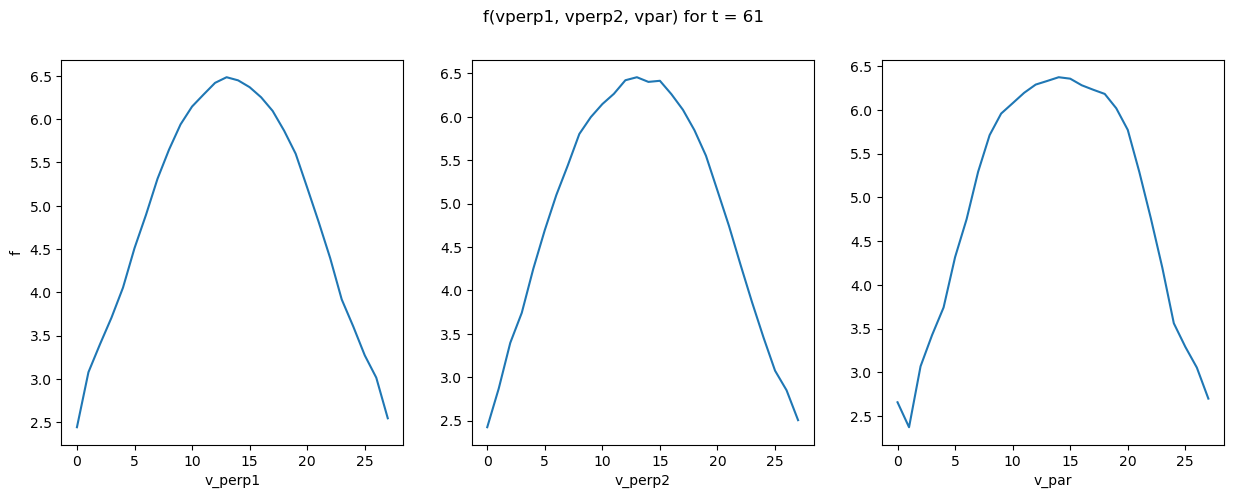

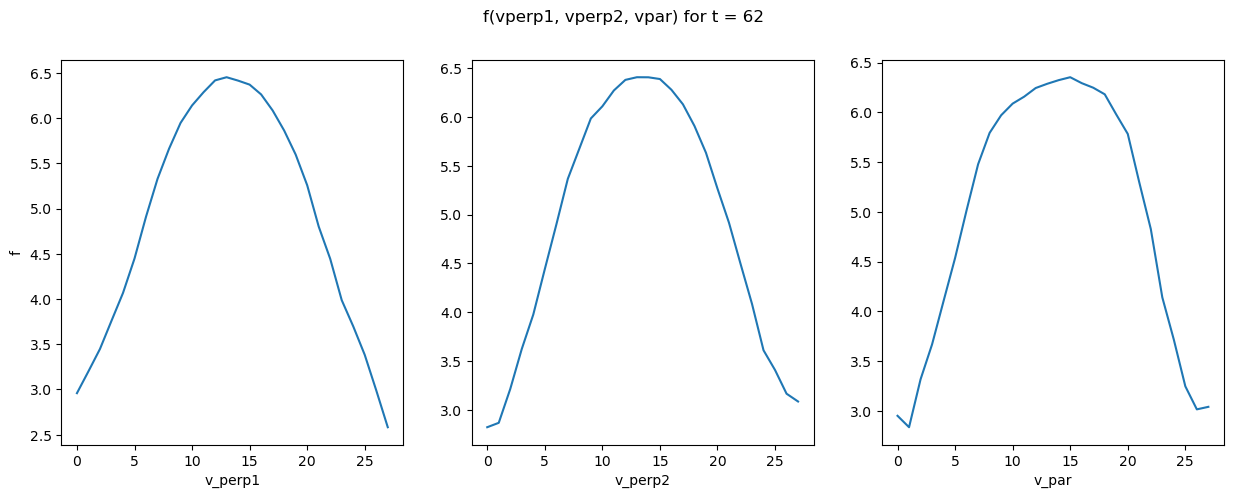

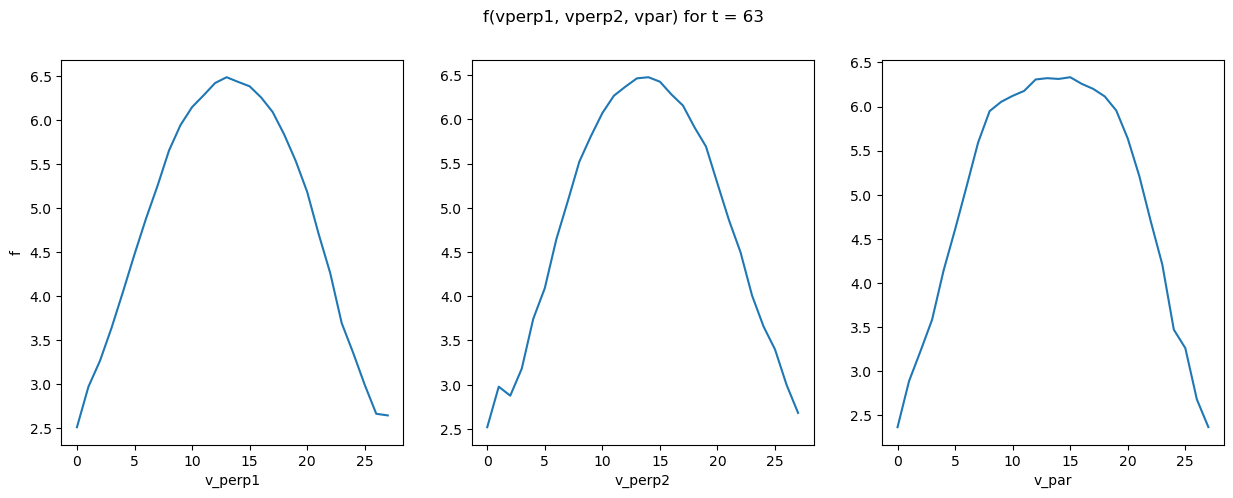

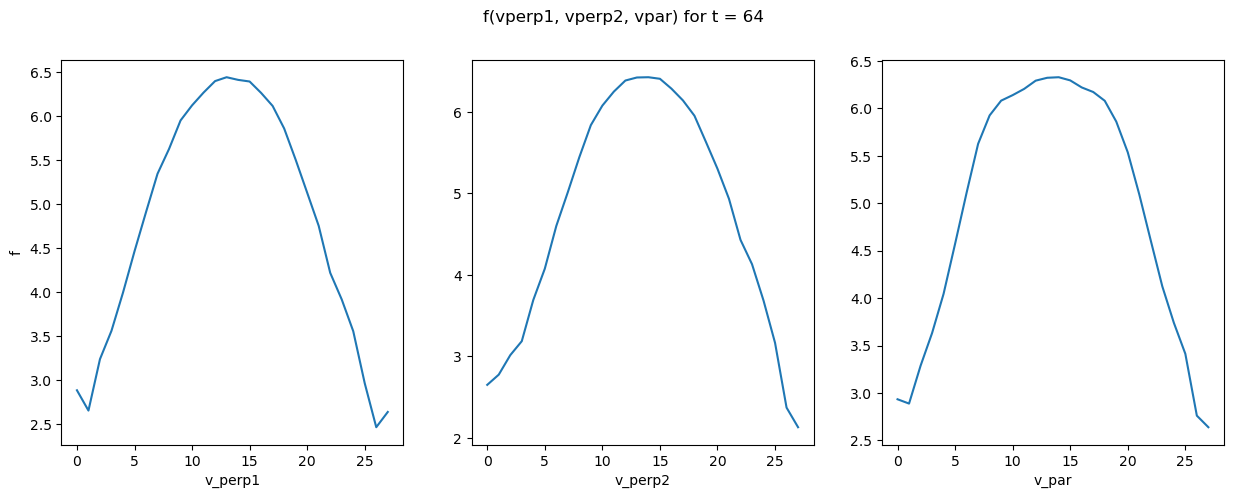

In [9]:
t_list = [58, 59, 60, 61, 62, 63, 64]
for t in t_list:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(np.log10(fx[:, t]), label='fx')
    ax[1].plot(np.log10(fy[:, t]), label='fy')
    ax[2].plot(np.log10(fz[:, t]), label='fz')
    ax[0].set_xlabel('v_perp1')
    ax[0].set_ylabel('f')
    ax[1].set_xlabel('v_perp2')
    ax[2].set_xlabel('v_par')
    fig.suptitle(f'f(vperp1, vperp2, vpar) for t = {t}')

In [10]:
subs = [r"{\perp 1}", r"{\perp 2}", r"{\parallel}"]
# subs = ["L", "M", "N"]
je = [100, 123, 156]
[rf"$J_{subs[i]} E_{subs[i]} = {je[i]:.2e}$" for i in range(3)]

['$J_{\\perp 1} E_{\\perp 1} = 1.00e+02$',
 '$J_{\\perp 2} E_{\\perp 2} = 1.23e+02$',
 '$J_{\\parallel} E_{\\parallel} = 1.56e+02$']

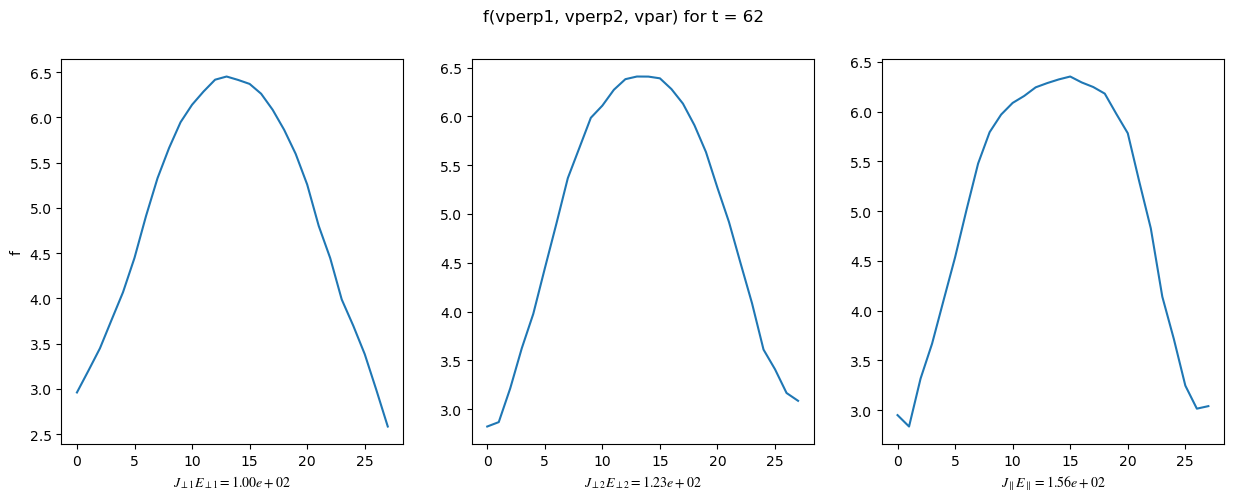

In [11]:
t_list = [62]
axs = [rf"$J_{subs[i]}E_{subs[i]} = {je[i]:.2e}$" for i in range(3)]
for t in t_list:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(np.log10(fx[:, t]), label='fx')
    ax[1].plot(np.log10(fy[:, t]), label='fy')
    ax[2].plot(np.log10(fz[:, t]), label='fz')
    ax[0].set_xlabel(axs[0])
    ax[0].set_ylabel('f')
    ax[1].set_xlabel(axs[1])
    ax[2].set_xlabel(axs[2])
    fig.suptitle(f'f(vperp1, vperp2, vpar) for t = {t}')